# General pipeline

In [2]:
import os
import warnings
import logging
import itertools

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

warnings.filterwarnings("ignore")

logging.basicConfig(level=logging.INFO, format="%(message)s")
log = logging.getLogger("StationPipeline")


class StationarityAnalysisPipeline:
    def __init__(
        self,
        era5_nc_path:   str,
        era5_var:       str,
        interp_nc_path: str,
        interp_var:     str,
        output_dir:     str = "stationarity_results",
        h_bins:         int = 20,
    ):
        self.era5_nc_path   = era5_nc_path
        self.era5_var       = era5_var
        self.interp_nc_path = interp_nc_path
        self.interp_var     = interp_var
        self.output_dir     = output_dir
        self.h_bins         = h_bins

        # Fixed internal names – no need to pass as params
        self.lat_col  = "lat"
        self.lon_col  = "lon"
        self.date_col = "date"

        os.makedirs(output_dir, exist_ok=True)

        self.era5_vals        = None
        self.era5_lats        = None
        self.era5_lons        = None
        self.interp_grid_mean = None
        self.interp_grid_var  = None
        self.summary_rows     = []

    # ── Load ──────────────────────────────────────────────────────────
    def load_data(self):
        log.info("Loading data ...")

        ds_era5          = xr.open_dataset(self.era5_nc_path)
        self.era5_lats   = ds_era5["lat"].values
        self.era5_lons   = ds_era5["lon"].values
        self.era5_vals   = ds_era5[self.era5_var].values       # (time, lat, lon)

        ds_interp             = xr.open_dataset(self.interp_nc_path)
        ds_interp_aligned     = ds_interp.reindex_like(ds_era5, method="nearest")
        vals_interp           = ds_interp_aligned[self.interp_var].values

        self.interp_grid_mean = np.nanmean(vals_interp, axis=0)
        self.interp_grid_var  = np.nanvar(vals_interp,  axis=0)

        log.info("  ERA5 shape   : %s", self.era5_vals.shape)
        log.info("  Interp shape : %s", vals_interp.shape)

    # ── Shared map helper ──────────────────────────────────────────────
    def _spatial_map(self, data, title, label, filename, cmap="RdYlBu_r"):
        proj   = ccrs.PlateCarree()
        extent = [float(self.era5_lons.min()), float(self.era5_lons.max()),
                  float(self.era5_lats.min()), float(self.era5_lats.max())]

        fig, ax = plt.subplots(figsize=(11, 6), subplot_kw={"projection": proj})
        im = ax.pcolormesh(
            self.era5_lons, self.era5_lats, data,
            cmap=cmap, transform=proj,
            vmin=np.nanpercentile(data, 2),
            vmax=np.nanpercentile(data, 98),
        )
        plt.colorbar(im, ax=ax, label=label, shrink=0.75, pad=0.04)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
        ax.add_feature(cfeature.BORDERS,   linestyle=":", linewidth=0.6)
        ax.add_feature(cfeature.STATES,    alpha=0.35, linewidth=0.4)
        ax.set_extent(extent, crs=proj)
        ax.set_title(title, fontsize=11, pad=8)
        plt.tight_layout()

        path = os.path.join(self.output_dir, filename)
        plt.savefig(path, dpi=150, bbox_inches="tight")
        plt.show()     # ← display plot
        plt.close()

    # ── 1st Moment ────────────────────────────────────────────────────
    def test_first_moment(self):
        era5_mean = np.nanmean(self.era5_vals, axis=0)
        mu_std    = float(np.nanstd(era5_mean))
        mu_range  = float(np.nanmax(era5_mean) - np.nanmin(era5_mean))

        self._spatial_map(
            era5_mean,
            "1st Moment: ERA5 Mean μ(x)\nStationary → uniform colour  |  Gradient → Violated",
            "Temperature (K)", "moment1_era5.png",
        )

        st_std, st_range = np.nan, np.nan
        if self.interp_grid_mean is not None:
            st_std   = float(np.nanstd(self.interp_grid_mean))
            st_range = float(np.nanmax(self.interp_grid_mean) - np.nanmin(self.interp_grid_mean))
            self._spatial_map(
                self.interp_grid_mean,
                "1st Moment: Interpolated Mean μ(x)\nStationary → uniform colour  |  Gradient → Violated",
                "Temperature (K)", "moment1_interp.png",
            )

        verdict = "VIOLATED" if mu_std > 0.5 else "Satisfied"
        log.info("\n── 1st Moment μ(x) Results ───────────────────────────")
        log.info("  ERA5   : std=%.4f  range=%.4f", mu_std,  mu_range)
        log.info("  Interp : std=%.4f  range=%.4f", st_std,  st_range)
        log.info("  Verdict: %s  (non-constant μ → stationarity %s)", verdict, verdict)

        self.summary_rows.append({
            "Test":           "1st Moment μ(x)",
            "ERA5_std":       round(mu_std,   4),
            "ERA5_range":     round(mu_range, 4),
            "Interp_std":     round(st_std,   4),
            "Interp_range":   round(st_range, 4),
            "Interpretation": verdict,
        })

    # ── 2nd Moment ────────────────────────────────────────────────────
    def test_second_moment(self):
        era5_var = np.nanvar(self.era5_vals, axis=0)
        v_std    = float(np.nanstd(era5_var))
        v_range  = float(np.nanmax(era5_var) - np.nanmin(era5_var))

        self._spatial_map(
            era5_var,
            "2nd Moment: ERA5 Variance σ²(x)\nStationary → uniform colour  |  Gradient → Violated",
            "Variance (K²)", "moment2_era5.png", cmap="YlOrRd",
        )

        int_v_std, int_v_range = np.nan, np.nan
        if self.interp_grid_var is not None:
            int_v_std   = float(np.nanstd(self.interp_grid_var))
            int_v_range = float(np.nanmax(self.interp_grid_var) - np.nanmin(self.interp_grid_var))
            self._spatial_map(
                self.interp_grid_var,
                "2nd Moment: Interpolated Variance σ²(x)\nStationary → uniform colour  |  Gradient → Violated",
                "Variance (K²)", "moment2_interp.png", cmap="YlOrRd",
            )

        verdict = "VIOLATED" if v_std > 0.5 else "Satisfied"
        log.info("\n── 2nd Moment σ²(x) Results ──────────────────────────")
        log.info("  ERA5   : std=%.4f  range=%.4f", v_std,     v_range)
        log.info("  Interp : std=%.4f  range=%.4f", int_v_std, int_v_range)
        log.info("  Verdict: %s  (non-constant σ² → stationarity %s)", verdict, verdict)

        self.summary_rows.append({
            "Test":           "2nd Moment σ²(x)",
            "ERA5_std":       round(v_std,       4),
            "ERA5_range":     round(v_range,     4),
            "Interp_std":     round(int_v_std,   4),
            "Interp_range":   round(int_v_range, 4),
            "Interpretation": verdict,
        })

    # ── Covariance vs h ───────────────────────────────────────────────
    def test_covariance_h(self):
        n_t, n_lat, n_lon = self.era5_vals.shape
        mu = np.nanmean(self.era5_vals, axis=0)

        flat_vals = self.era5_vals.reshape(n_t, -1).T
        flat_mu   = mu.flatten()
        flat_lats = np.repeat(self.era5_lats, n_lon)
        flat_lons = np.tile(self.era5_lons,   n_lat)

        valid     = ~np.all(np.isnan(flat_vals), axis=1)
        flat_vals = flat_vals[valid]
        flat_mu   = flat_mu[valid]
        flat_lats = flat_lats[valid]
        flat_lons = flat_lons[valid]

        max_pairs = 5000
        pairs = list(itertools.combinations(range(flat_vals.shape[0]), 2))
        if len(pairs) > max_pairs:
            rng   = np.random.default_rng(42)
            pairs = [pairs[i] for i in rng.choice(len(pairs), max_pairs, replace=False)]

        h_vals, cov_vals, dlon_vals, dlat_vals = [], [], [], []
        for i, j in pairs:
            dlat = float(flat_lats[i] - flat_lats[j])
            dlon = float(flat_lons[i] - flat_lons[j])
            h    = float(np.sqrt(dlat**2 + dlon**2))
            zi   = flat_vals[i] - flat_mu[i]
            zj   = flat_vals[j] - flat_mu[j]
            mask = ~(np.isnan(zi) | np.isnan(zj))
            if mask.sum() < 10:
                continue
            h_vals.append(h)
            cov_vals.append(float(np.mean(zi[mask] * zj[mask])))
            dlon_vals.append(abs(dlon))
            dlat_vals.append(abs(dlat))

        h_arr    = np.array(h_vals)
        cov_arr  = np.array(cov_vals)
        dlon_arr = np.array(dlon_vals)
        dlat_arr = np.array(dlat_vals)

        bins     = np.linspace(0, h_arr.max(), self.h_bins + 1)
        bin_mid  = 0.5 * (bins[:-1] + bins[1:])
        bin_mean, bin_std = [], []
        for lo, hi in zip(bins[:-1], bins[1:]):
            sel = (h_arr >= lo) & (h_arr < hi)
            bin_mean.append(np.mean(cov_arr[sel]) if sel.sum() > 0 else np.nan)
            bin_std.append(np.std(cov_arr[sel])   if sel.sum() > 0 else np.nan)
        bin_mean = np.array(bin_mean)
        bin_std  = np.array(bin_std)

        # Plot 1 – Omnidirectional
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.scatter(h_arr, cov_arr, alpha=0.15, s=8, color="steelblue", label="Pair covariance")
        ax.plot(bin_mid, bin_mean, "r-o", ms=5, lw=1.8, label="Bin mean C(h)")
        ax.fill_between(bin_mid, bin_mean - bin_std, bin_mean + bin_std,
                        alpha=0.2, color="red", label="±1 std")
        ax.axhline(0, color="black", lw=0.8, linestyle="--")
        ax.set_xlabel("Separation h (degrees)")
        ax.set_ylabel("Covariance C(xi, xj)")
        ax.set_title("Covariance vs Spatial Separation h  [ERA5]\n"
                     "Stationary → smooth decay with h only, independent of position")
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(self.output_dir, "covariance_vs_h.png"), dpi=150, bbox_inches="tight")
        plt.show()
        plt.close()

        # Plot 2 – Directional (anisotropy check)
        fig, ax = plt.subplots(figsize=(10, 5))
        for mask, color, lbl in [
            (dlat_arr >= dlon_arr, "blue",  "N–S direction"),
            (dlat_arr <  dlon_arr, "green", "E–W direction"),
        ]:
            bm = [
                np.mean(cov_arr[mask & (h_arr >= lo) & (h_arr < hi)])
                if (mask & (h_arr >= lo) & (h_arr < hi)).sum() > 0 else np.nan
                for lo, hi in zip(bins[:-1], bins[1:])
            ]
            ax.plot(bin_mid, bm, "o-", color=color, lw=1.8, ms=5, label=lbl)
        ax.axhline(0, color="black", lw=0.8, linestyle="--")
        ax.set_xlabel("Separation h (degrees)")
        ax.set_ylabel("Covariance C(h)")
        ax.set_title("Directional Covariance vs h  [ERA5]\n"
                     "N-S ≠ E-W → anisotropy (additional non-stationarity)")
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(self.output_dir, "covariance_directional.png"), dpi=150, bbox_inches="tight")
        plt.show()
        plt.close()

        c0      = float(bin_mean[0]) if not np.isnan(bin_mean[0]) else np.nan
        c_range = float(np.nanmax(bin_mean) - np.nanmin(bin_mean))
        log.info("\n── Covariance C(h) Results ───────────────────────────")
        log.info("  C(h=0) sill : %.4f", c0)
        log.info("  C(h) range  : %.4f  (large = strongly decays with distance)", c_range)
        log.info("  Verdict     : Check directional plot — N-S ≠ E-W means anisotropy")

        self.summary_rows.append({
            "Test":           "Covariance C(h)",
            "ERA5_std":       round(float(np.nanstd(bin_mean)), 4),
            "ERA5_range":     round(c_range, 4),
            "Interp_std":     np.nan,
            "Interp_range":   np.nan,
            "Interpretation": f"C(h=0)={round(c0,3)} — see directional plot for anisotropy",
        })

    # ── run ───────────────────────────────────────────────────────────
    def run(self):
        self.load_data()
        self.test_first_moment()
        self.test_second_moment()
        self.test_covariance_h()

        df = pd.DataFrame(self.summary_rows)
        csv_path = os.path.join(self.output_dir, "stationarity_summary.csv")
        df.to_csv(csv_path, index=False)

        log.info("\n── Final Summary ─────────────────────────────────────")
        log.info("\n%s", df[["Test", "ERA5_std", "ERA5_range",
                              "Interp_std", "Interp_range",
                              "Interpretation"]].to_string(index=False))
        log.info("\nOutputs saved in: %s", self.output_dir)

# Air Temperature

Loading data ...
  ERA5 shape   : (5844, 29, 54)
  Interp shape : (5844, 29, 54)


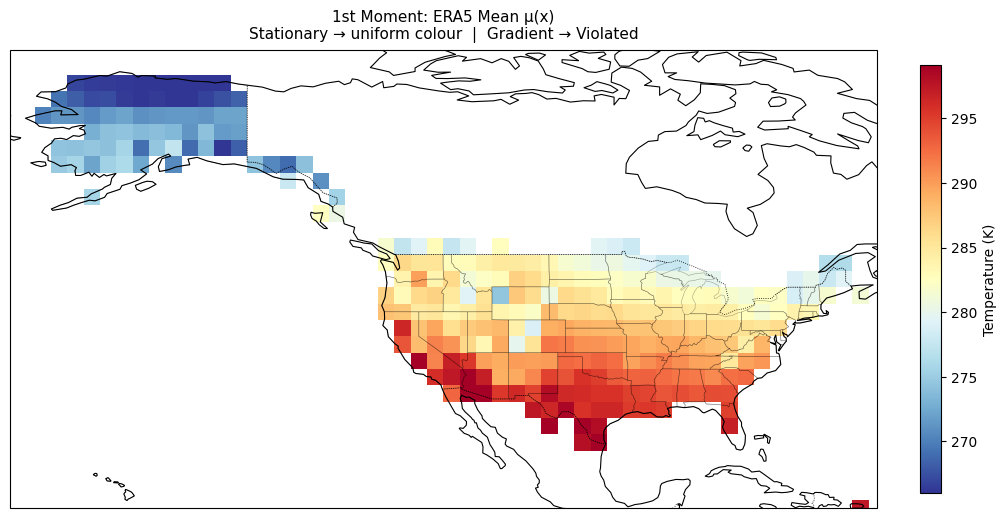

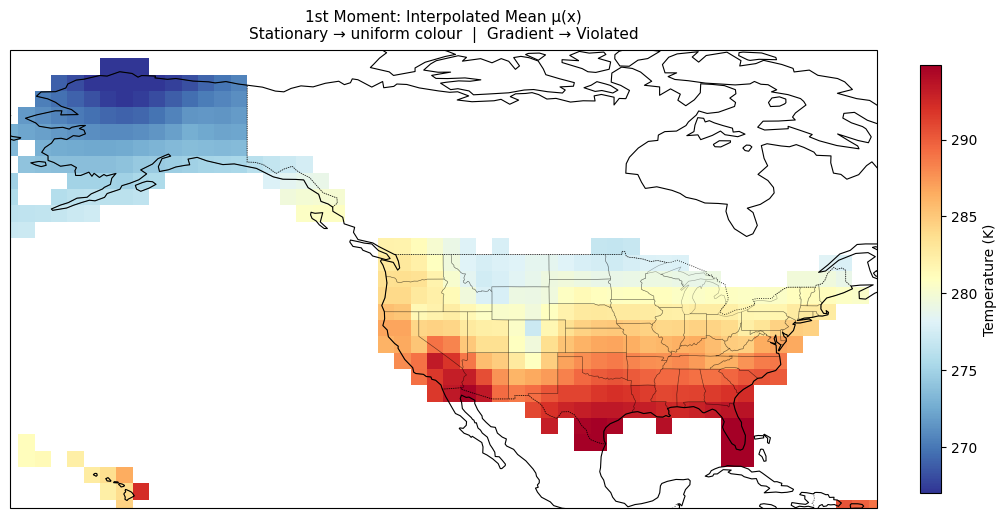


── 1st Moment μ(x) Results ───────────────────────────
  ERA5   : std=8.9463  range=41.0033
  Interp : std=7.3186  range=31.4913
  Verdict: VIOLATED  (non-constant μ → stationarity VIOLATED)


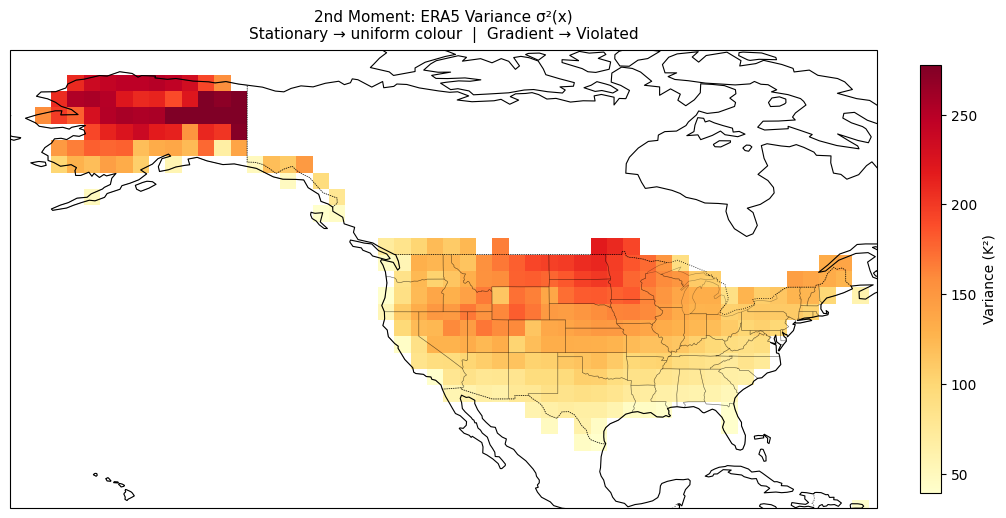

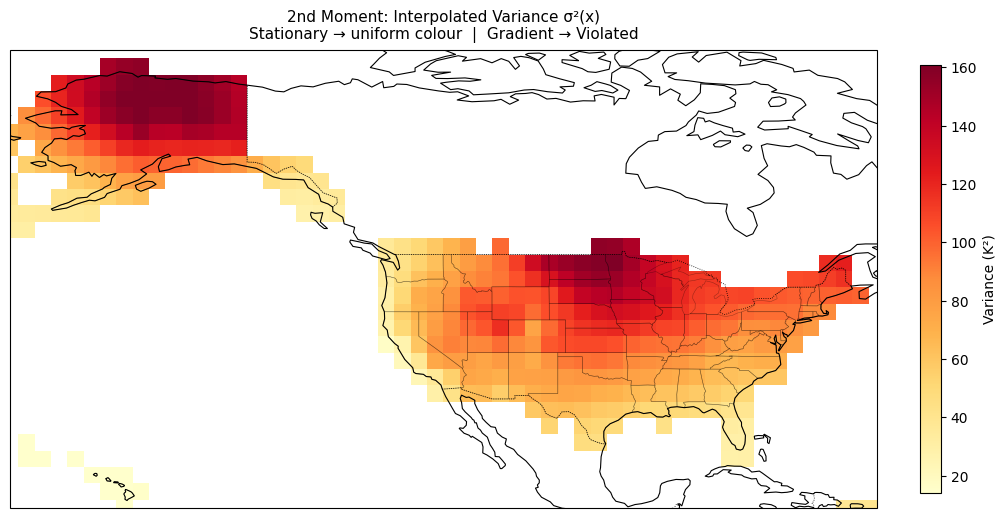


── 2nd Moment σ²(x) Results ──────────────────────────
  ERA5   : std=59.8510  range=346.8293
  Interp : std=39.1536  range=157.8106
  Verdict: VIOLATED  (non-constant σ² → stationarity VIOLATED)


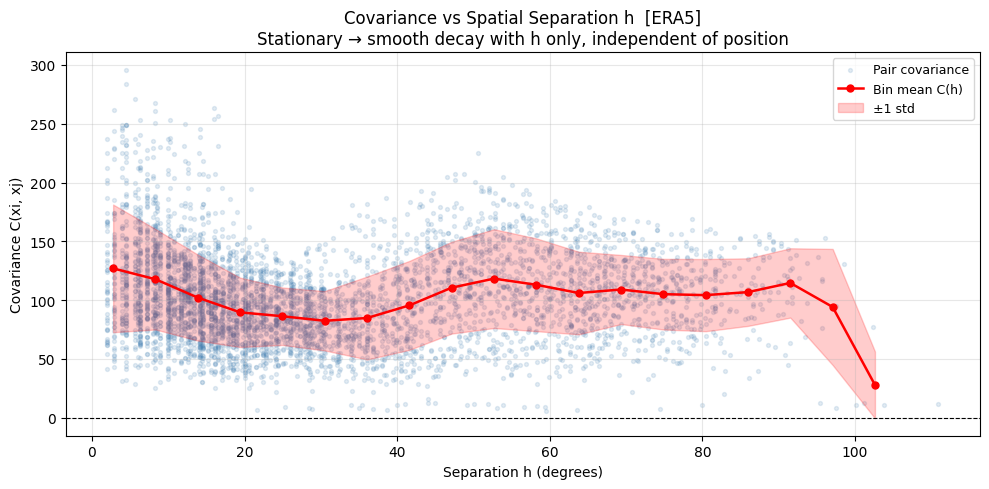

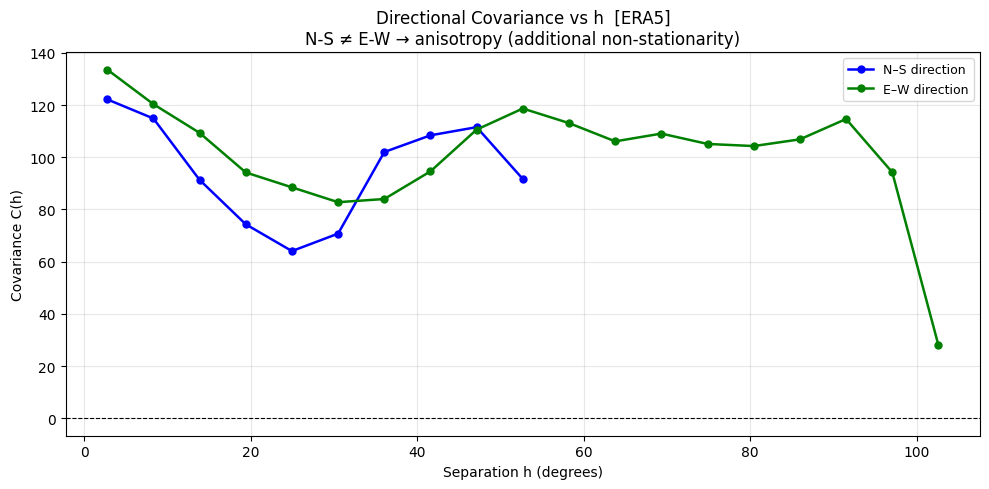


── Covariance C(h) Results ───────────────────────────
  C(h=0) sill : 127.0383
  C(h) range  : 99.0564  (large = strongly decays with distance)
  Verdict     : Check directional plot — N-S ≠ E-W means anisotropy

── Final Summary ─────────────────────────────────────

            Test  ERA5_std  ERA5_range  Interp_std  Interp_range                                       Interpretation
 1st Moment μ(x)    8.9463     41.0033      7.3186       31.4913                                             VIOLATED
2nd Moment σ²(x)   59.8510    346.8293     39.1536      157.8106                                             VIOLATED
 Covariance C(h)   20.7351     99.0564         NaN           NaN C(h=0)=127.038 — see directional plot for anisotropy

Outputs saved in: Stationarity_results\Airtemperature


In [3]:
pipe = StationarityAnalysisPipeline(
    era5_nc_path   = r"era5_temperature\era5_clipped.nc",
    era5_var       = "t2m",
    interp_nc_path = r"distribution_comparison\temp\interp_clipped_AirTemperature.nc",
    interp_var     = "AirTemperature",
    output_dir     = r"Stationarity_results\Airtemperature",
    h_bins         = 20,
    )
pipe.run()

# Soil Temp

Loading data ...
  ERA5 shape   : (5844, 29, 54)
  Interp shape : (5844, 29, 54)


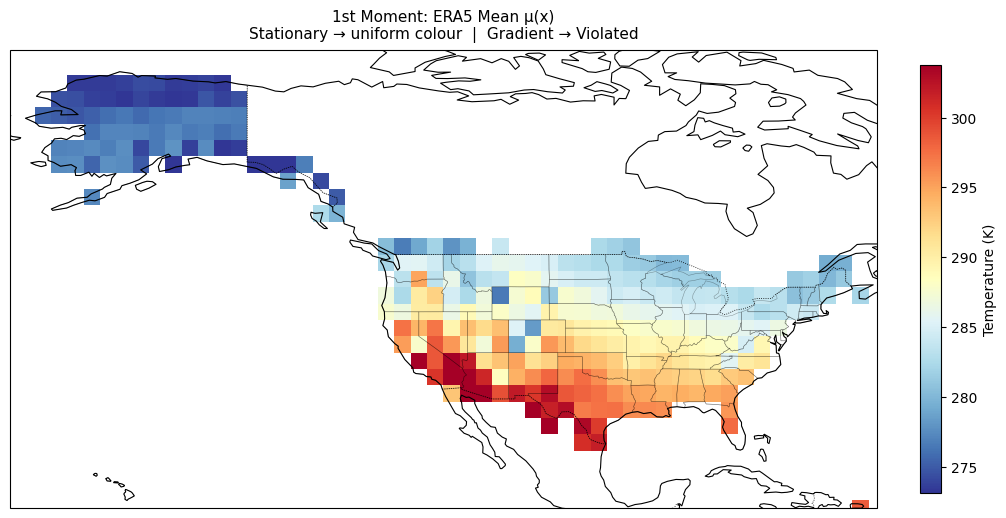

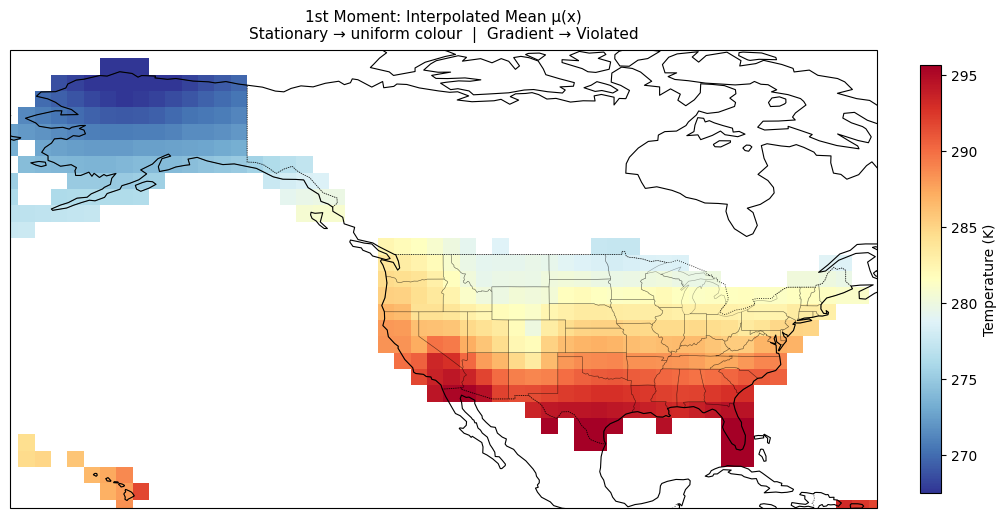


── 1st Moment μ(x) Results ───────────────────────────
  ERA5   : std=8.5533  range=50.2941
  Interp : std=7.7627  range=31.1047
  Verdict: VIOLATED  (non-constant μ → stationarity VIOLATED)


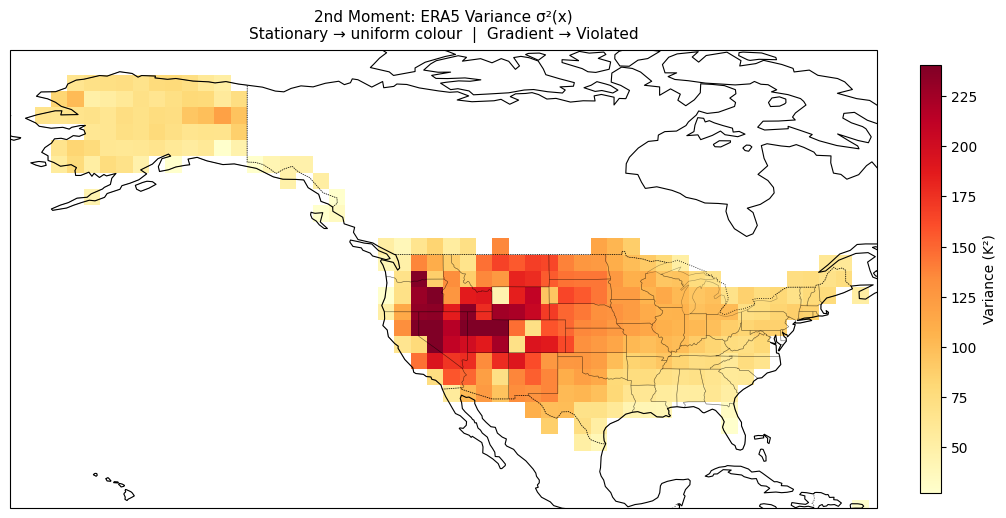

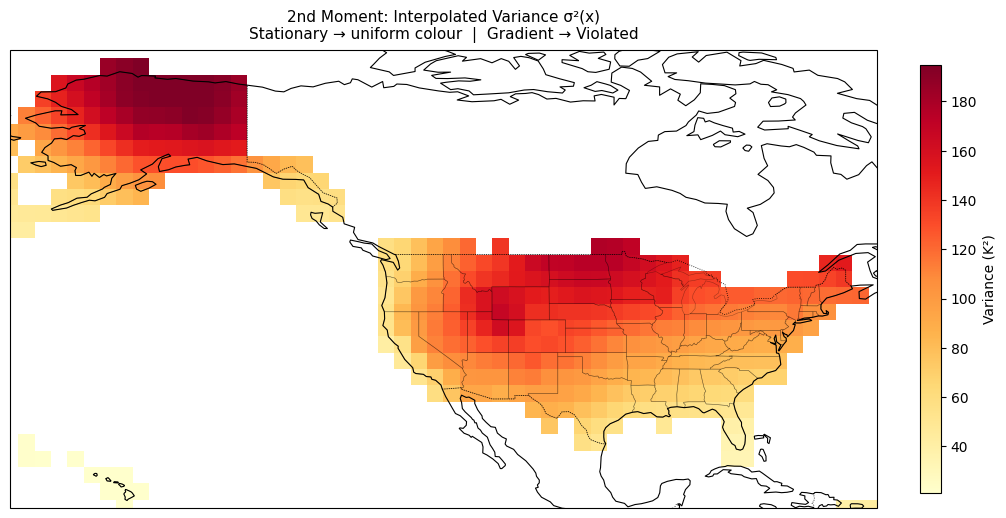


── 2nd Moment σ²(x) Results ──────────────────────────
  ERA5   : std=51.3967  range=267.7820
  Interp : std=44.3907  range=185.3142
  Verdict: VIOLATED  (non-constant σ² → stationarity VIOLATED)


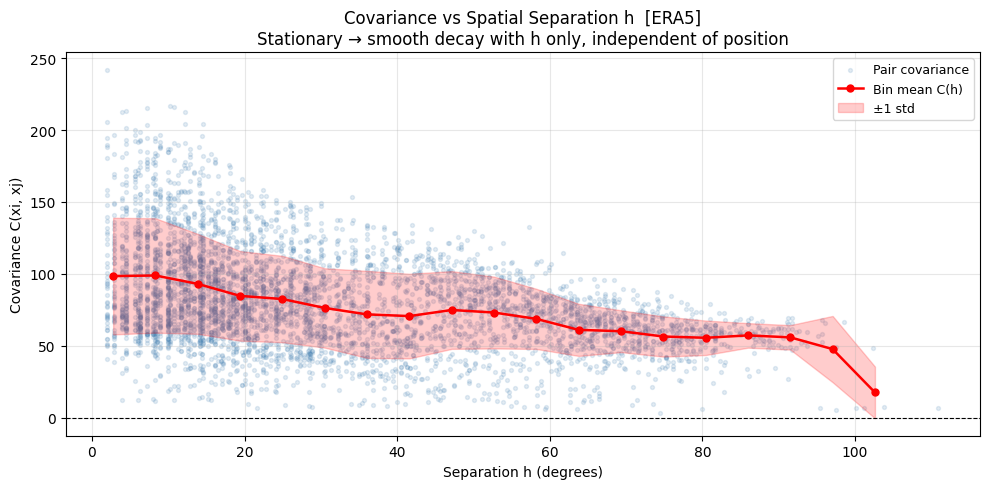

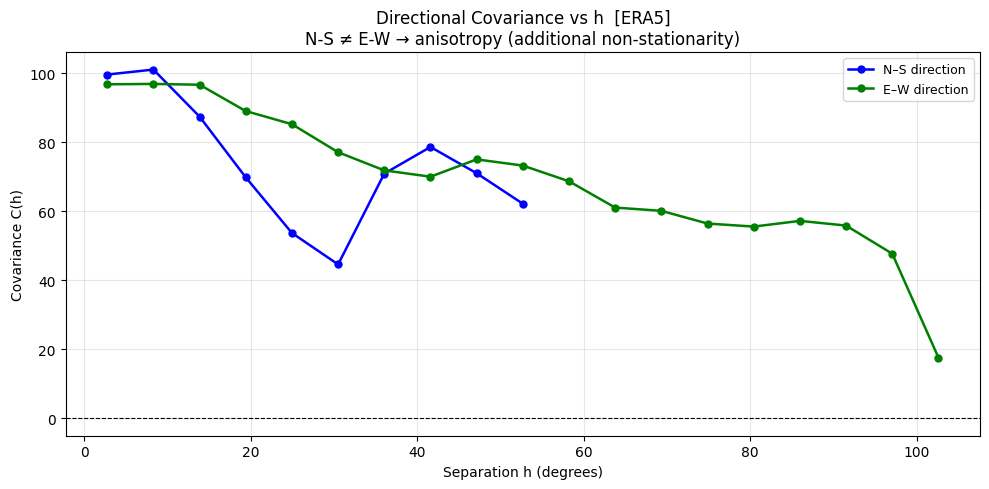


── Covariance C(h) Results ───────────────────────────
  C(h=0) sill : 98.4790
  C(h) range  : 81.2970  (large = strongly decays with distance)
  Verdict     : Check directional plot — N-S ≠ E-W means anisotropy

── Final Summary ─────────────────────────────────────

            Test  ERA5_std  ERA5_range  Interp_std  Interp_range                                      Interpretation
 1st Moment μ(x)    8.5533     50.2941      7.7627       31.1047                                            VIOLATED
2nd Moment σ²(x)   51.3967    267.7820     44.3907      185.3142                                            VIOLATED
 Covariance C(h)   18.8741     81.2970         NaN           NaN C(h=0)=98.479 — see directional plot for anisotropy

Outputs saved in: Stationarity_results\Soil temperature


In [4]:
pipe = StationarityAnalysisPipeline(
    era5_nc_path   = r"era5_soil_temperature\era5_clipped.nc",
    era5_var       = "stl1",
    interp_nc_path = r"distribution_comparison\soil_temp\interp_clipped_SoilTemperature.nc",
    interp_var     = "SoilTemperature",
    output_dir     = r"Stationarity_results\Soil temperature",
    h_bins         = 20,
    )
pipe.run()

# Soil Moisture

Loading data ...
  ERA5 shape   : (5844, 29, 54)
  Interp shape : (5844, 29, 54)


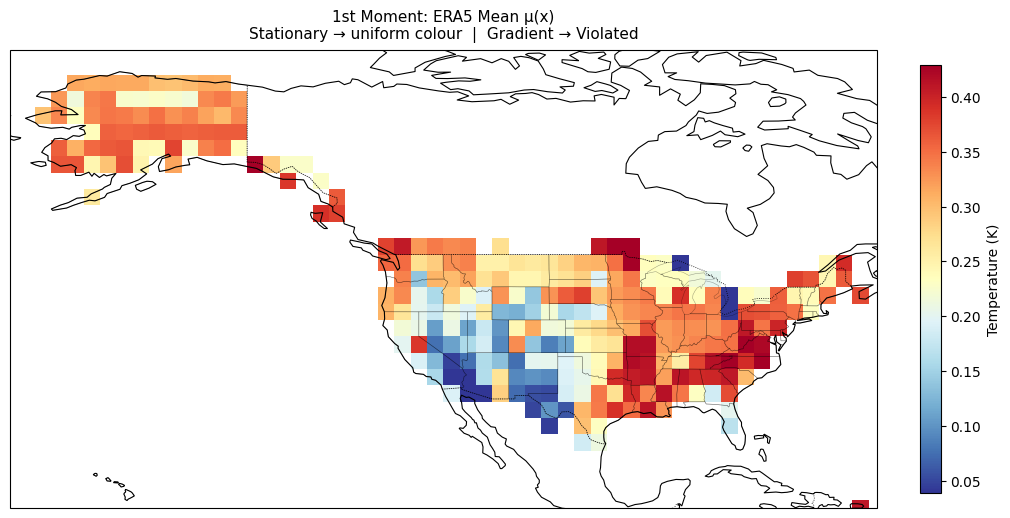

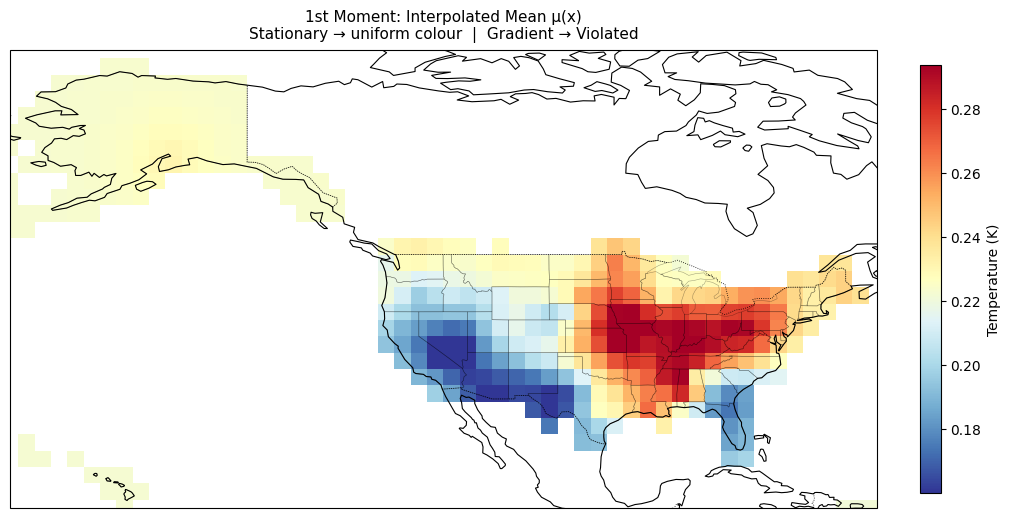


── 1st Moment μ(x) Results ───────────────────────────
  ERA5   : std=0.1019  range=0.6395
  Interp : std=0.0304  range=0.1631
  Verdict: Satisfied  (non-constant μ → stationarity Satisfied)


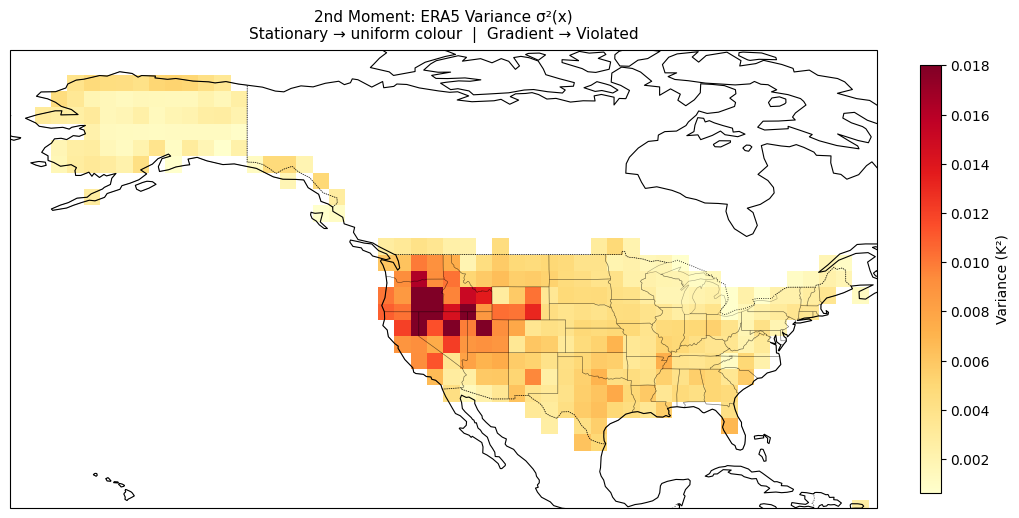

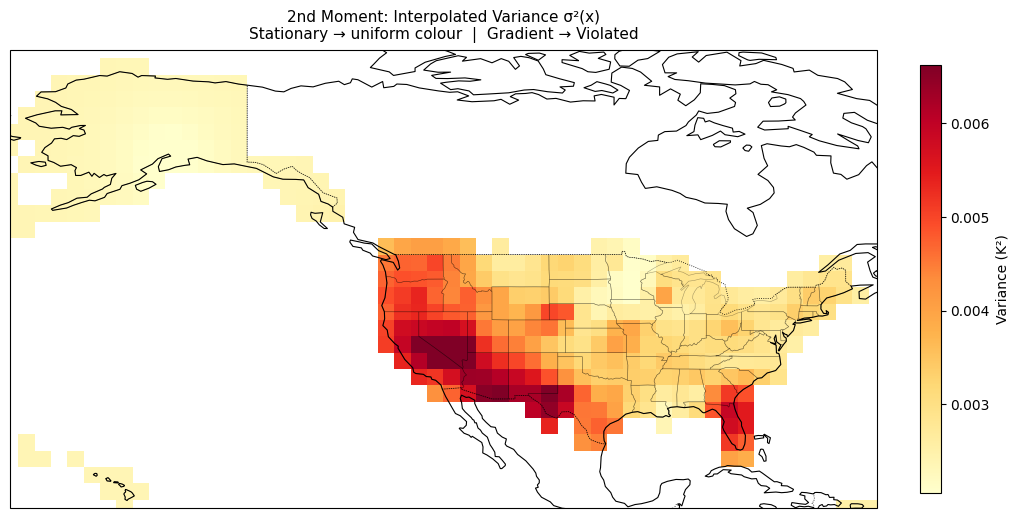


── 2nd Moment σ²(x) Results ──────────────────────────
  ERA5   : std=0.0040  range=0.0311
  Interp : std=0.0013  range=0.0059
  Verdict: Satisfied  (non-constant σ² → stationarity Satisfied)


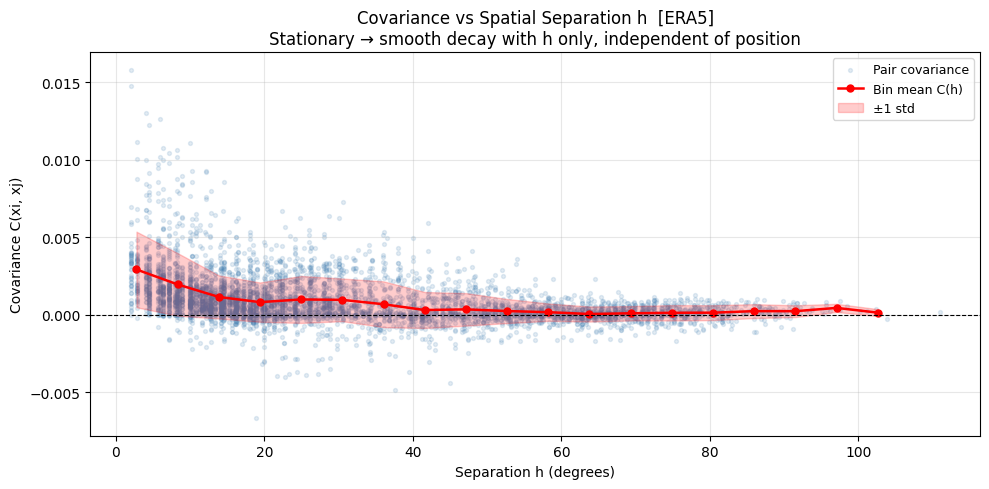

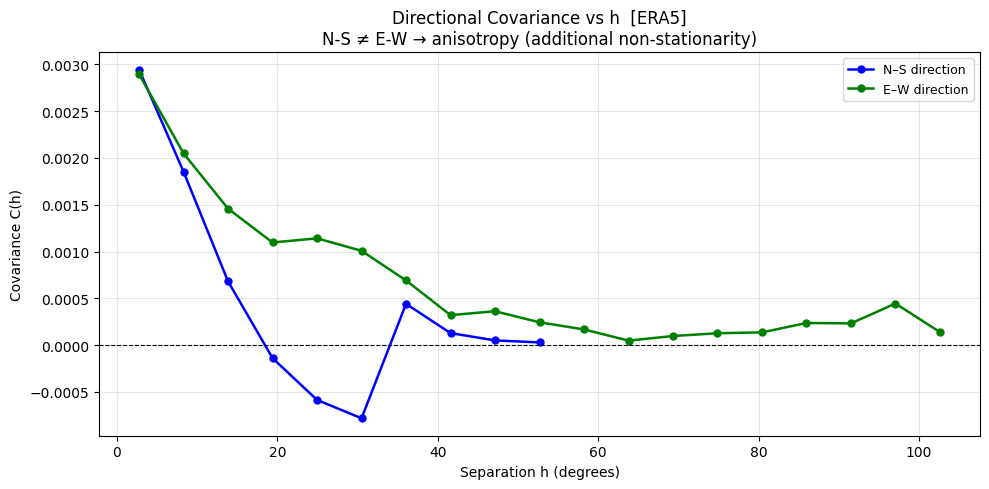


── Covariance C(h) Results ───────────────────────────
  C(h=0) sill : 0.0029
  C(h) range  : 0.0029  (large = strongly decays with distance)
  Verdict     : Check directional plot — N-S ≠ E-W means anisotropy

── Final Summary ─────────────────────────────────────

            Test  ERA5_std  ERA5_range  Interp_std  Interp_range                                     Interpretation
 1st Moment μ(x)    0.1019      0.6395      0.0304        0.1631                                          Satisfied
2nd Moment σ²(x)    0.0040      0.0311      0.0013        0.0059                                          Satisfied
 Covariance C(h)    0.0007      0.0029         NaN           NaN C(h=0)=0.003 — see directional plot for anisotropy

Outputs saved in: Stationarity_results\Soil_moisture


In [3]:
pipe = StationarityAnalysisPipeline(
    era5_nc_path   = r"era5_soil_moisture\era5_clipped.nc",
    era5_var       = "swvl1",
    interp_nc_path = r"distribution_comparison\soil_moist\interp_clipped_SoilMoisture10cm.nc",
    interp_var     = "SoilMoisture10cm",
    output_dir     = r"Stationarity_results\Soil_moisture",
    h_bins         = 20,
    )
pipe.run()

# Rainfall ppt.

Loading data ...
  ERA5 shape   : (5844, 29, 54)
  Interp shape : (5844, 29, 54)


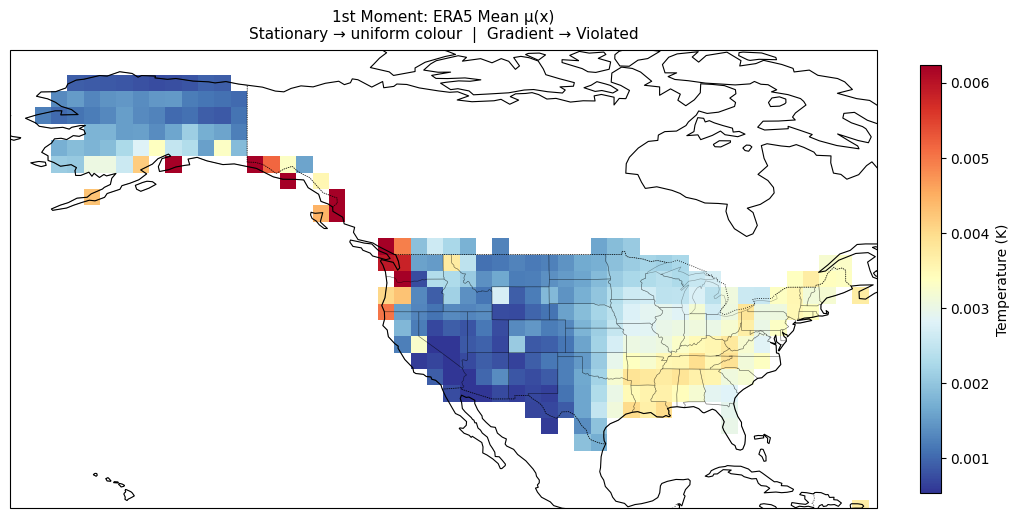

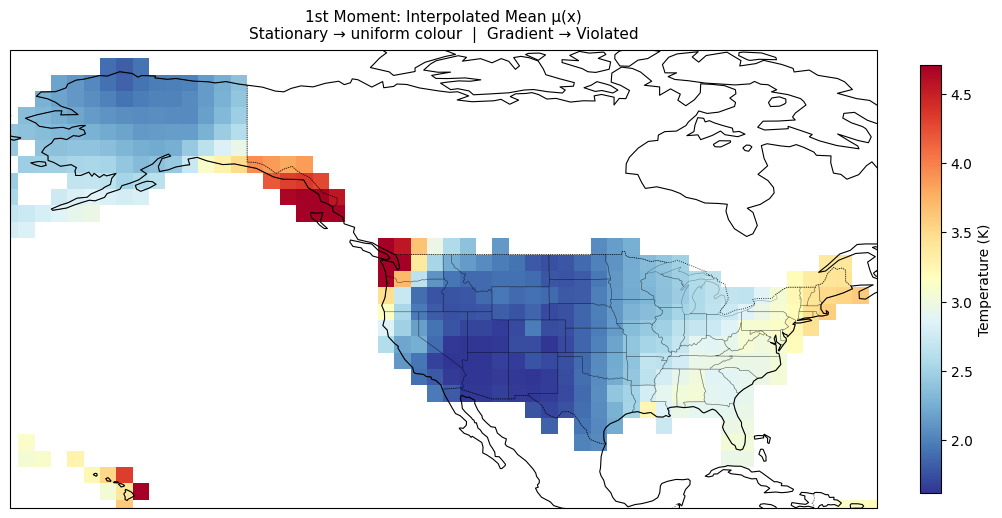


── 1st Moment μ(x) Results ───────────────────────────
  ERA5   : std=0.0014  range=0.0090
  Interp : std=0.7310  range=4.6415
  Verdict: Satisfied  (non-constant μ → stationarity Satisfied)


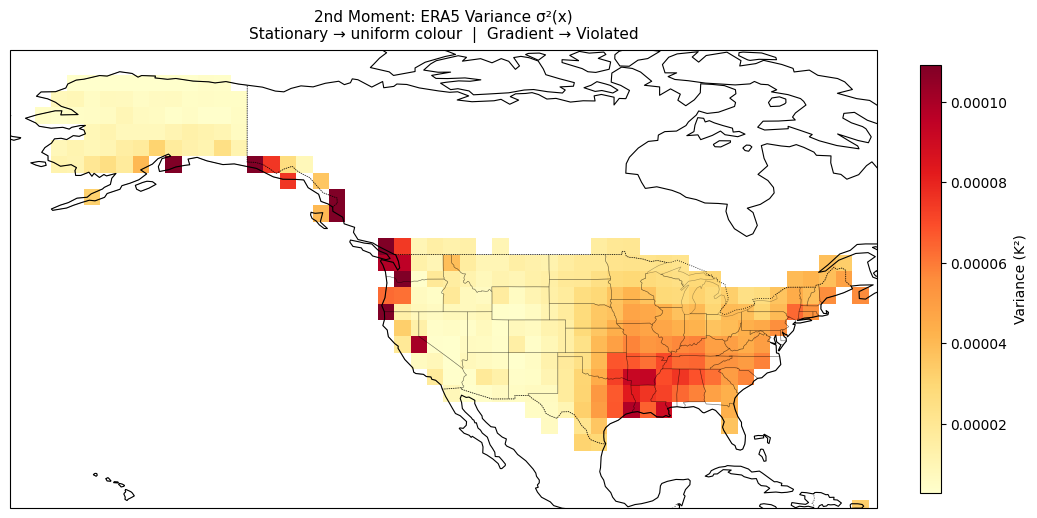

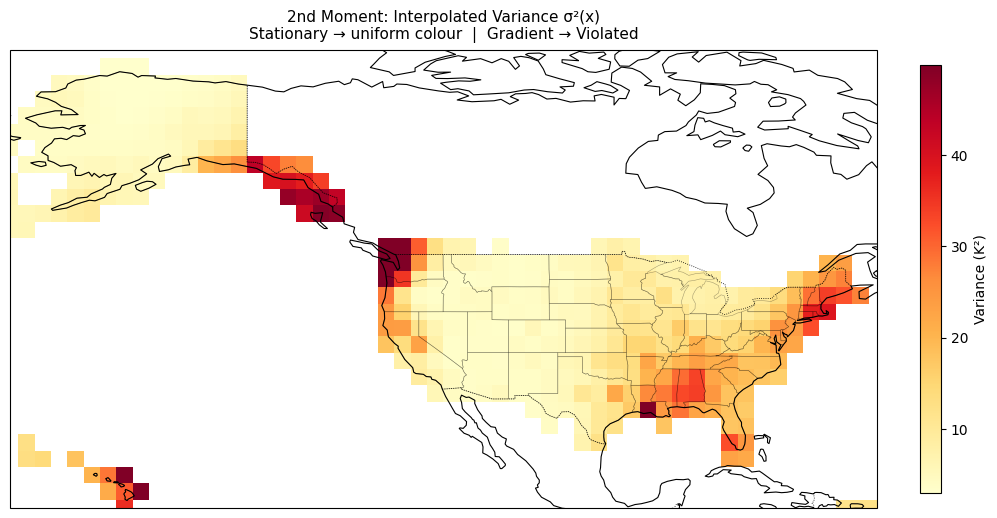


── 2nd Moment σ²(x) Results ──────────────────────────
  ERA5   : std=0.0000  range=0.0002
  Interp : std=19.6416  range=259.8658
  Verdict: Satisfied  (non-constant σ² → stationarity Satisfied)


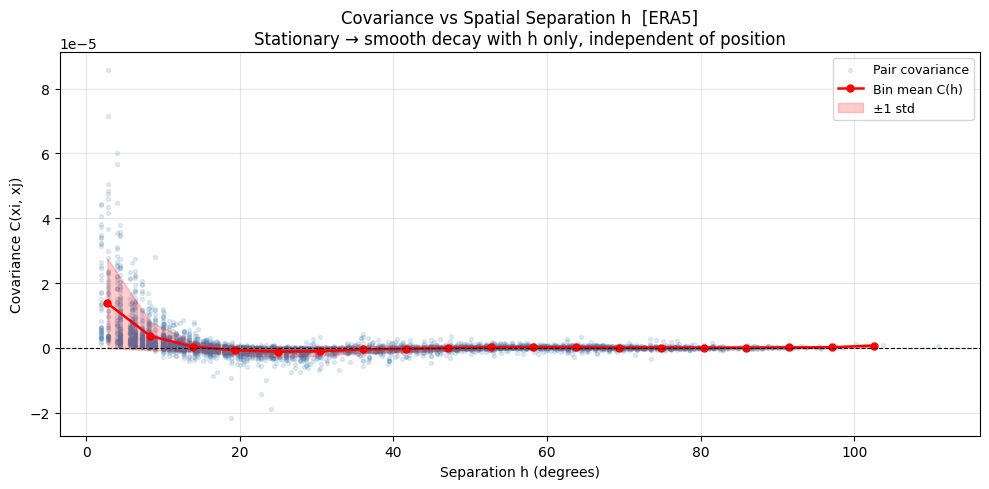

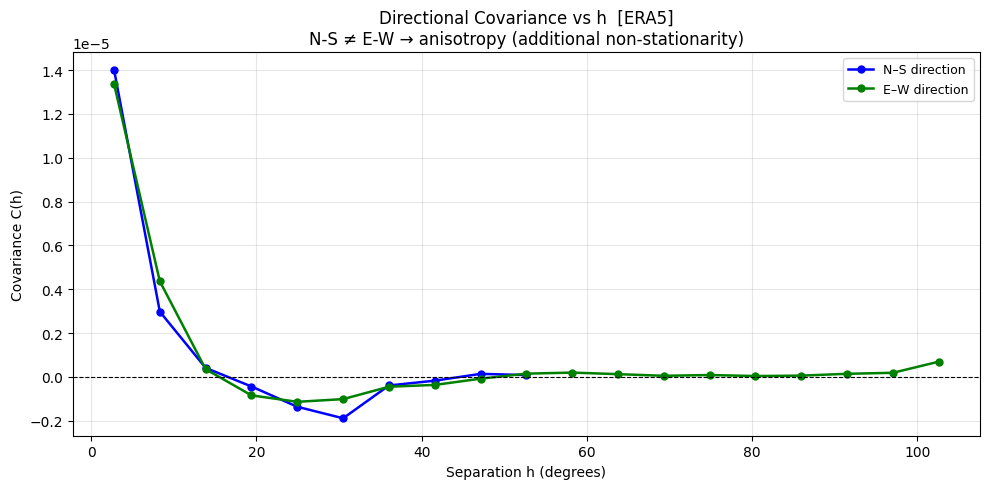


── Covariance C(h) Results ───────────────────────────
  C(h=0) sill : 0.0000
  C(h) range  : 0.0000  (large = strongly decays with distance)
  Verdict     : Check directional plot — N-S ≠ E-W means anisotropy

── Final Summary ─────────────────────────────────────

            Test  ERA5_std  ERA5_range  Interp_std  Interp_range                                   Interpretation
 1st Moment μ(x)    0.0014      0.0090      0.7310        4.6415                                        Satisfied
2nd Moment σ²(x)    0.0000      0.0002     19.6416      259.8658                                        Satisfied
 Covariance C(h)    0.0000      0.0000         NaN           NaN C(h=0)=0.0 — see directional plot for anisotropy

Outputs saved in: Stationarity_results\Rainfall


In [5]:
pipe = StationarityAnalysisPipeline(
    era5_nc_path   = r"era5_total_ppt\era5_clipped.nc",
    era5_var       = "tp",
    interp_nc_path = r"distribution_comparison\rainfall\interp_clipped_Precipitation.nc",
    interp_var     = "Precipitation",
    output_dir     = r"Stationarity_results\Rainfall",
    h_bins         = 20,
    )
pipe.run()

# Relative Humidity

Loading data ...
  ERA5 shape   : (5844, 29, 54)
  Interp shape : (5844, 29, 54)


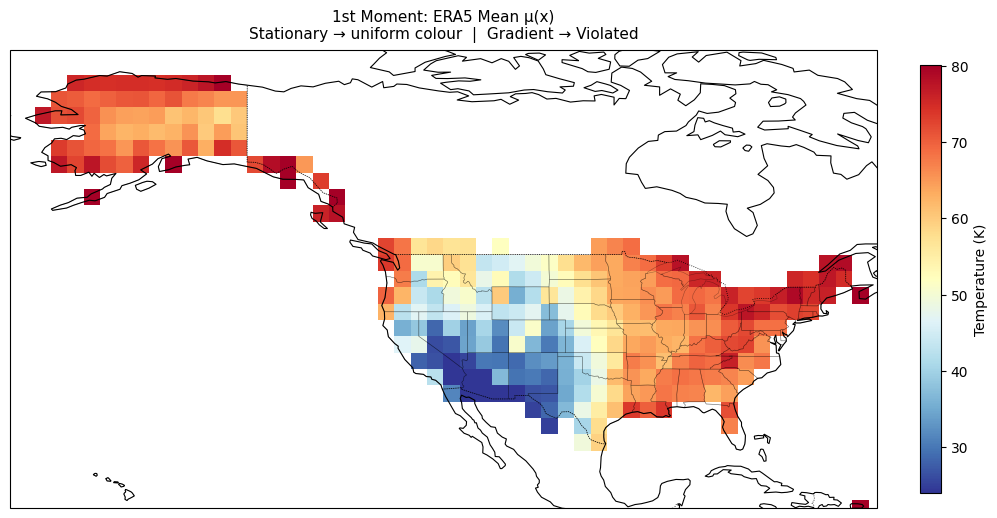

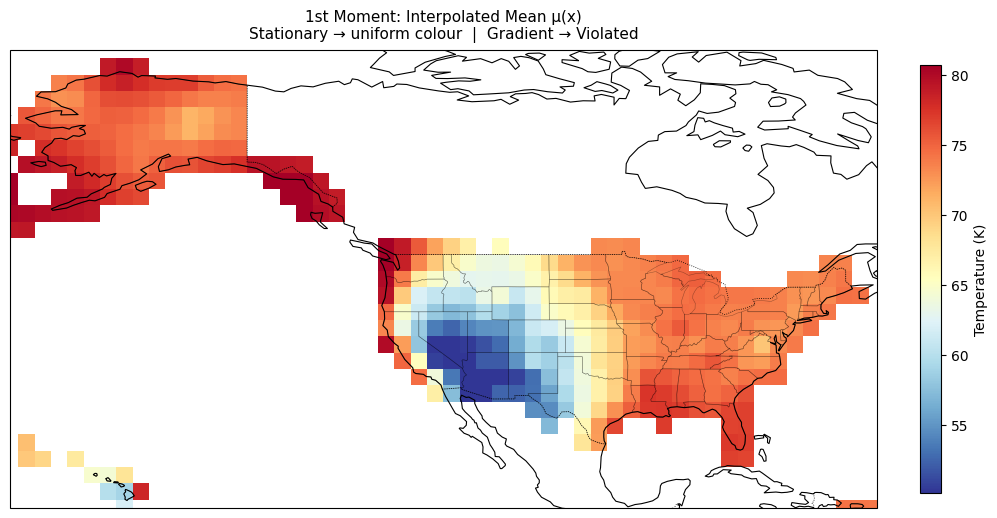


── 1st Moment μ(x) Results ───────────────────────────
  ERA5   : std=15.5786  range=65.8669
  Interp : std=7.9018  range=36.6021
  Verdict: VIOLATED  (non-constant μ → stationarity VIOLATED)


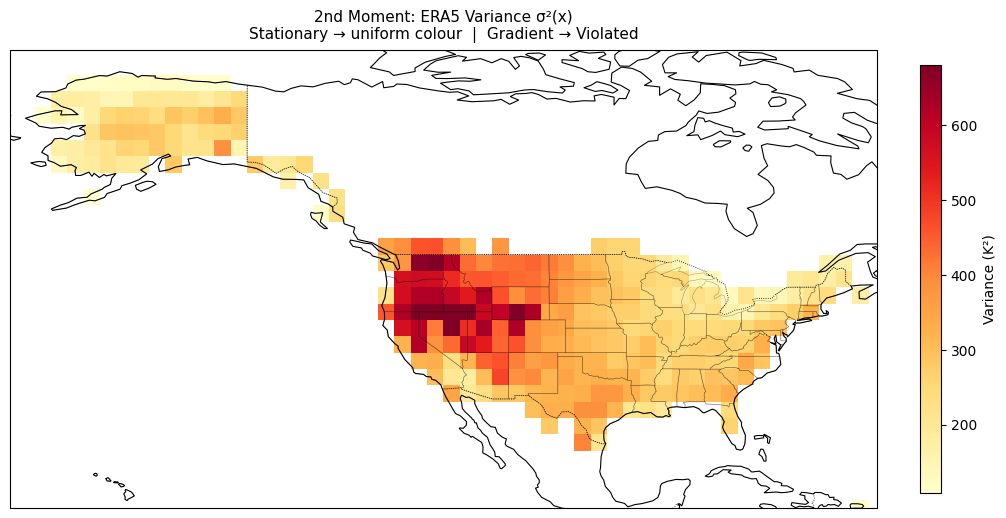

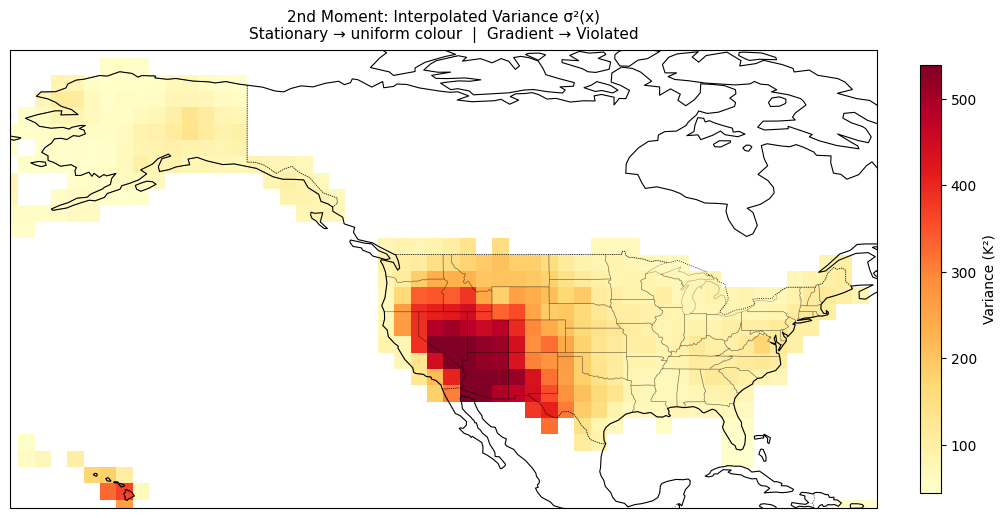


── 2nd Moment σ²(x) Results ──────────────────────────
  ERA5   : std=135.9193  range=743.3518
  Interp : std=130.7471  range=627.9410
  Verdict: VIOLATED  (non-constant σ² → stationarity VIOLATED)


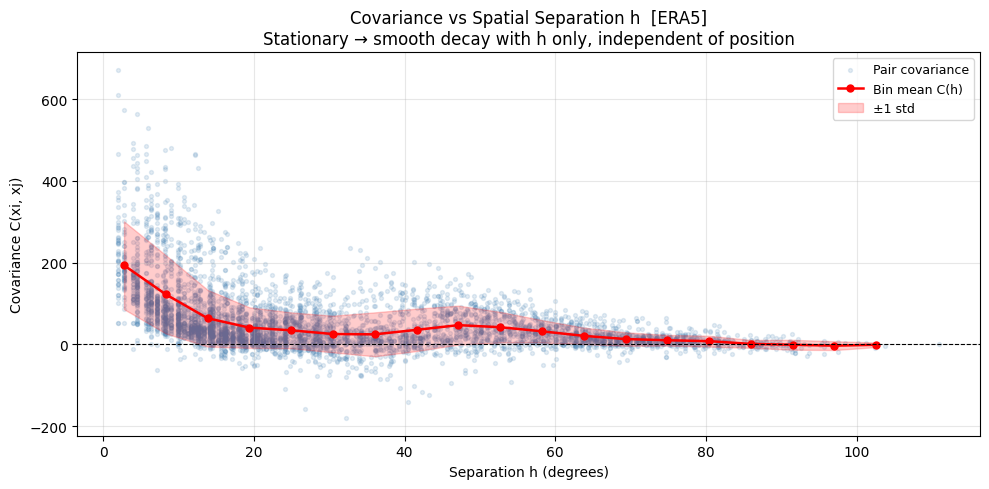

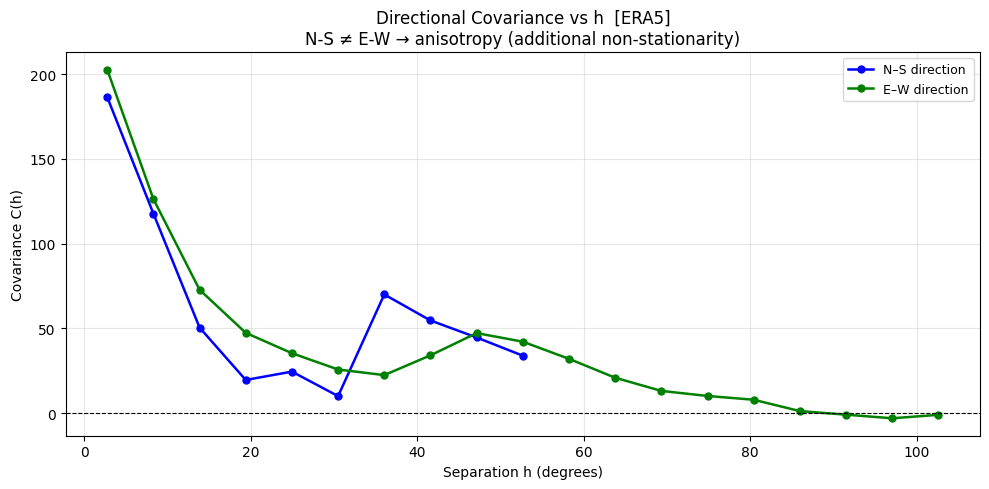


── Covariance C(h) Results ───────────────────────────
  C(h=0) sill : 193.3414
  C(h) range  : 196.4083  (large = strongly decays with distance)
  Verdict     : Check directional plot — N-S ≠ E-W means anisotropy

── Final Summary ─────────────────────────────────────

            Test  ERA5_std  ERA5_range  Interp_std  Interp_range                                       Interpretation
 1st Moment μ(x)   15.5786     65.8669      7.9018       36.6021                                             VIOLATED
2nd Moment σ²(x)  135.9193    743.3518    130.7471      627.9410                                             VIOLATED
 Covariance C(h)   46.5033    196.4083         NaN           NaN C(h=0)=193.341 — see directional plot for anisotropy

Outputs saved in: Stationarity_results\humidity


In [6]:
pipe = StationarityAnalysisPipeline(
    era5_nc_path   = r"era5_dewtemperature\era5_relative_humidity.nc",
    era5_var       = "relative_humidity",
    interp_nc_path = r"distribution_comparison\Relative_Humidity\interp_clipped_RelativeHumidity.nc",
    interp_var     = "RelativeHumidity",
    output_dir     = r"Stationarity_results\humidity",
    h_bins         = 20,
    )
pipe.run()